<a href="https://colab.research.google.com/github/Anmol756/-churn-on-banking-dataset-with-Deep-Neural-Network/blob/main/Depp-neural-network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [62]:
#1. Load dataset

df = pd.read_csv('/content/sample_data/Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [63]:
# Drop irrelevant columns (IDs and Names don't predict churn!)
X = df.iloc[:, 3:-1].values
y = df.iloc[:, -1].values

In [64]:
#2. Encoding Categorical Data
# Gender (Label Encoding)
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

# Geography (OneHot Encoding)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])],
remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [65]:
# 3. Splitting and Scaling

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# Scaling is CRITICAL for Neural Networks
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [67]:
# 4. Building the DNN

model = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)), # Explicitly define the input layer
    Dense(units = 12, activation = 'relu'), # First Hidden Layer
    Dropout(0.2), # Prevents overfitting
    Dense(units = 8, activation = 'relu'), # Second Hidden Layer
    Dense(units = 1, activation = 'sigmoid') # Output layer for binary classification
])

In [68]:
# 5. Compiling and Training

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [69]:
print("Training the model...")
model.fit(X_train, y_train, batch_size=32, epochs=50, verbose=1)

Training the model...
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7408 - loss: 0.5649
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7964 - loss: 0.4648
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8067 - loss: 0.4455
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8121 - loss: 0.4357
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8267 - loss: 0.4146
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8338 - loss: 0.4033
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8325 - loss: 0.3964
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8341 - loss: 0.3899
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8382 - loss: 0.3858
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8406 - loss: 0.3807
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8410 - loss: 0.3760
Epoch 12/50
250/250 ━━━━━━━━━━

In [70]:
# 6. Evaluation

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8650 - loss: 0.3375

Test Accuracy: 86.50%


In [71]:
# 1. Generate predictions (probabilities)
y_pred_prob = model.predict(X_test)
# 2. Convert probabilities to binary (True/False) using a 0.5 threshold
y_pred = (y_pred_prob > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [72]:
# 3. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1542   65]
 [ 205  188]]


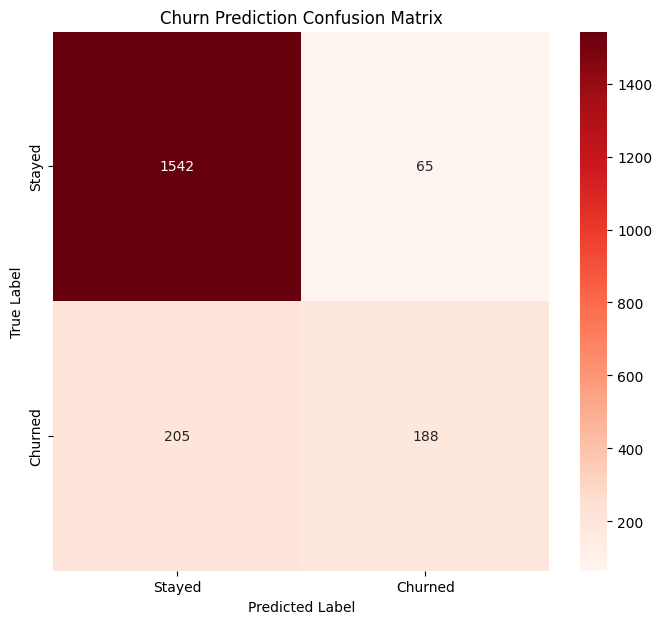

In [89]:
# 4. Plotting
plt.figure(figsize = (8, 7))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Reds',
      xticklabels = ['Stayed', 'Churned'],
      yticklabels = ['Stayed', 'Churned'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Churn Prediction Confusion Matrix')
plt.show()

In [74]:
# 5. Print Detailed Report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.74      0.48      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000

